In [1]:
# Import libraries and load saved models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report, confusion_matrix)

results = pd.read_csv("../../ml-service/data\processed/test_predictions.csv")
results['datetimeLocal'] = pd.to_datetime(results['datetimeLocal'])
results.head()

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_52104\1279193560.py:11: SyntaxWarning: invalid escape sequence '\p'
  results = pd.read_csv("../../ml-service/data\processed/test_predictions.csv")


,location_name,datetimeLocal,AQI,AQI_category,AQI_pred,AQI_category_pred
0,"Rabindra Sarobar, Kolkata - WBPCB",2022-04-25 01:00:00+05:30,68.562500,Satisfactory,69.037994,Satisfactory
1,"Bidhannagar, Kolkata - WBPCB",2022-04-25 01:00:00+05:30,65.207917,Satisfactory,65.182470,Satisfactory
2,"Fort William, Kolkata - WBPCB",2022-04-25 01:00:00+05:30,65.089583,Satisfactory,65.364710,Satisfactory
3,"Ballygunge, Kolkata - WBPCB",2022-04-25 01:00:00+05:30,74.741667,Satisfactory,75.138040,Satisfactory
4,"Jadavpur, Kolkata - WBPCB",2022-04-25 01:00:00+05:30,61.687500,Satisfactory,62.839478,Satisfactory


In [2]:
# Regression metrics - AQI value

y_true = results['AQI']
y_pred = results['AQI_pred']

rmse = mean_squared_error(y_true, y_pred) ** 0.5
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.3f}")

RMSE: 4.73
MAE:  2.54
R²:   0.921


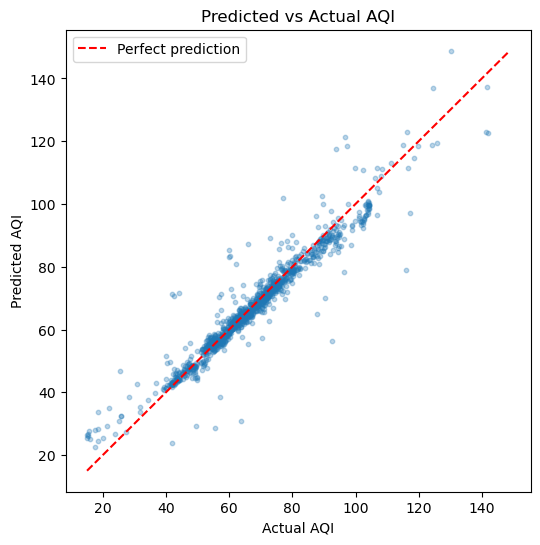

In [4]:
# Plot predicted AQI VS Actual AQI

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.3, s=10)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Predicted vs Actual AQI')
plt.legend()
plt.show()

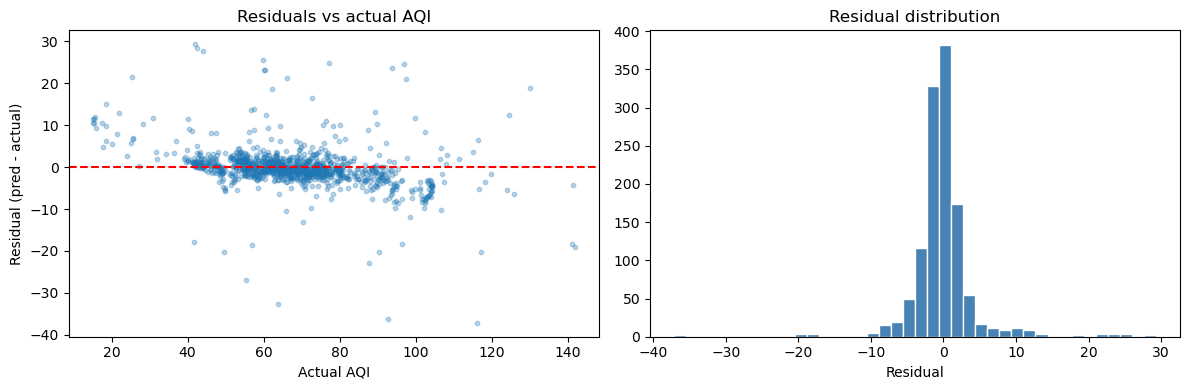

In [5]:
# Check whether errors are randomly scattered (good) or systematically biased at certain AQI levels (bad)

residuals = y_pred - y_true
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_true, residuals, alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Actual AQI')
axes[0].set_ylabel('Residual (pred - actual)')
axes[0].set_title('Residuals vs actual AQI')

axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residual')
plt.tight_layout()
plt.show()

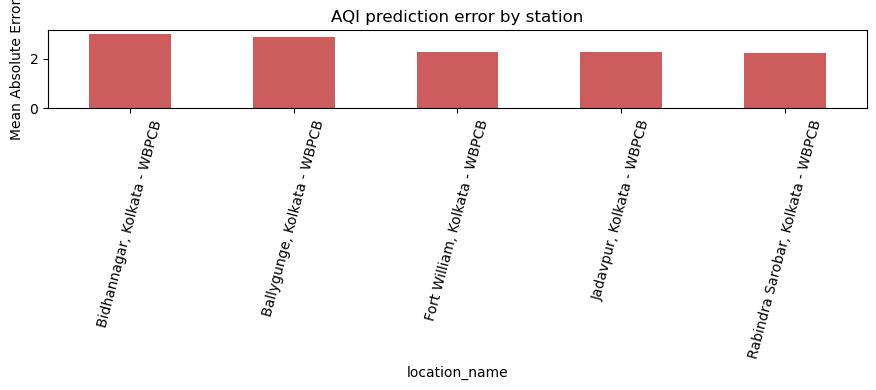

location_name
Bidhannagar, Kolkata - WBPCB         2.989481
Ballygunge, Kolkata - WBPCB          2.886205
Fort William, Kolkata - WBPCB        2.272817
Jadavpur, Kolkata - WBPCB            2.256942
Rabindra Sarobar, Kolkata - WBPCB    2.228602
Name: abs_error, dtype: float64

In [6]:
# Regression error by station

results['abs_error'] = (results['AQI_pred'] - results['AQI']).abs()
station_mae = results.groupby('location_name')['abs_error'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 4))
station_mae.plot(kind='bar', color='indianred')
plt.ylabel('Mean Absolute Error')
plt.title('AQI prediction error by station')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()
station_mae

In [7]:
# Classification metrics (AQI category)

y_true_c = results['AQI_category']
y_pred_c = results['AQI_category_pred']
acc = accuracy_score(y_true_c, y_pred_c)
f1_macro = f1_score(y_true_c, y_pred_c, average='macro')

print(f"Accuracy: {acc:.3f}")
print(f"F1 (macro): {f1_macro:.3f}")
print()
print(classification_report(y_true_c, y_pred_c)) 

Accuracy: 0.956
F1 (macro): 0.801

              precision    recall  f1-score   support

        Good       0.96      0.95      0.95       156
    Moderate       0.95      0.32      0.47        57
Satisfactory       0.96      0.99      0.97      1025

    accuracy                           0.96      1238
   macro avg       0.95      0.75      0.80      1238
weighted avg       0.96      0.96      0.95      1238



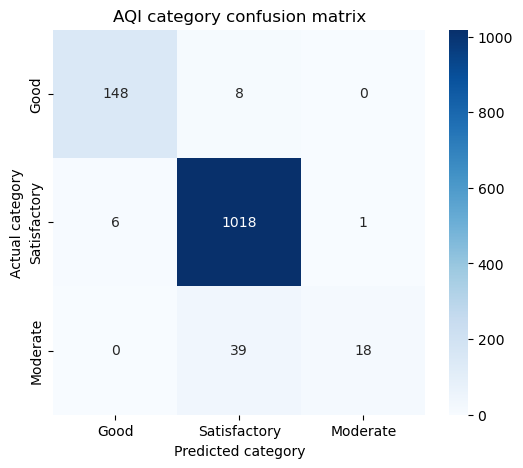

In [8]:
# Confusion Matrix

labels_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
labels_present = [l for l in labels_order if l in set(y_true_c) | set(y_pred_c)]
cm = confusion_matrix(y_true_c, y_pred_c, labels=labels_present)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_present, yticklabels=labels_present)
plt.xlabel('Predicted category')
plt.ylabel('Actual category')
plt.title('AQI category confusion matrix')
plt.show()